<a href="https://colab.research.google.com/github/AzraNA24/Deforestration-Drivers-Classification/blob/main/Deforestization_Drivers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inisialisasi**
---

## Import Earth Engine

In [1]:
import ee
ee.Authenticate()
ee.Initialize(project='deforestation-drivers-508922')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [60]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_DIR = '/content/drive/MyDrive/skripsi_data'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(f'{DATA_DIR}/patches', exist_ok=True)
os.makedirs(f'{DATA_DIR}/rasters', exist_ok=True)
os.makedirs(f'{DATA_DIR}/tables',  exist_ok=True)
os.makedirs(f'{DATA_DIR}/maps',    exist_ok=True)
os.makedirs(f'{DATA_DIR}/anim',    exist_ok=True)
print("Struktur folder:")
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    print('  '*level + os.path.basename(root) + '/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Struktur folder:
skripsi_data/
  patches/
  rasters/
  tables/
  maps/
  anim/


## Ambil Area

In [3]:
provinces = ee.FeatureCollection('FAO/GAUL/2015/level1')
kalteng = provinces.filter(ee.Filter.eq('ADM1_NAME', 'Kalimantan Tengah'))
aoi = kalteng.geometry()

### Pengecekan Area yang Diambil

In [8]:
print('Jumlah citra 2020:', processed.filterDate('2020-01-01', '2020-12-31').size().getInfo())
print('Jumlah citra 2025:', processed.filterDate('2025-01-01', '2025-12-31').size().getInfo())

Jumlah citra 2020: 197
Jumlah citra 2025: 137


Nah, karna di 2025 citranya jauh lebih sedikit, saya mau melihat range inputnya,

In [10]:
dates = processed.filterDate('2025-01-01', '2025-12-31').aggregate_array('system:time_start')
dates_list = dates.getInfo()
import datetime
print('Tanggal citra paling awal:', datetime.datetime.fromtimestamp(min(dates_list)/1000))
print('Tanggal citra paling akhir:', datetime.datetime.fromtimestamp(max(dates_list)/1000))

Tanggal citra paling awal: 2025-02-13 02:49:14.631000
Tanggal citra paling akhir: 2025-12-15 02:47:58.419000


Karna di tahun 2025 data terakhir muncul di Desember, itu berarti citra yang rendah mungkin karna tutupan awannya. Harusnya nggak massalah. Tapi untuk klarifikasi lebih jauh, saya melihat citra perbulan.

In [12]:
import pandas as pd

dates_list = processed.filterDate('2025-01-01', '2025-12-31').aggregate_array('system:time_start').getInfo()
months = [datetime.datetime.fromtimestamp(d/1000).month for d in dates_list]
print(pd.Series(months).value_counts().sort_index())

2      1
3      1
4      8
5     26
6     14
7     45
8     15
9     11
10     7
11     8
12     1
Name: count, dtype: int64


Kode ini nunjukin seberapa banyak citra yang muncul dalam satu bulan.

Dapat dilihat bahwa citra banyak diambil pada rentang Mei-Agustus yang bisa diklasifikasikan sebagai Kemarau.

Hal ini berarti composite berikut secara efektif "condong" merepresentasikan musim kemarau saja, yang bisa membuat bias sistematis dibanding composite 2020 yang mungkin terdistribusi lebih merata sepanjang tahun. Jadi, kita lakukan sedikit perbandingan.

### Visualisasi Distribusi Citra

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

**Ambil Citra Perbulan**

In [22]:
def get_monthly_counts(collection, year):
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    timestamps = (collection
                  .filterDate(start, end)
                  .aggregate_array('system:time_start')
                  .getInfo())

    if not timestamps:
        return pd.Series(0, index=range(1, 13), name=year)

    months = [datetime.fromtimestamp(d / 1000).month for d in timestamps]
    counts = pd.Series(months).value_counts().sort_index()

    counts = counts.reindex(range(1, 13), fill_value=0)
    counts.name = year
    return counts

In [23]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
df = pd.DataFrame({y: get_monthly_counts(processed, y) for y in years})
df.index = ['Jan','Feb','Mar','Apr','Mei','Jun',
            'Jul','Ags','Sep','Okt','Nov','Des']
df.index.name = 'Bulan'

print(df)
print("\nTotal per tahun:")
print(df.sum())

       2020  2021  2022  2023  2024  2025
Bulan                                    
Jan      12     0     3     0     1     0
Feb       9    16     1     0    13     1
Mar      15    12    24     2     6     1
Apr       8    37    11    13    15     8
Mei      30    14    35    22     7    26
Jun      45    20     4    18     7    14
Jul      14    34    11    16    12    45
Ags      39     9    13    31     6    15
Sep      15     8     7    39    25    11
Okt       7     1     0    30     4     7
Nov       2     6     2     3     7     8
Des       1     1     0     2     5     1

Total per tahun:
2020    197
2021    158
2022    111
2023    176
2024    108
2025    137
dtype: int64


In [24]:
dry_months = ['Mei','Jun','Jul','Ags']
wet_months = ['Nov','Des','Jan','Feb','Mar','Apr']

rekap = pd.DataFrame({
    'Total'      : df.sum(),
    'Kemarau'    : df.loc[dry_months].sum(),
    'Hujan'      : df.loc[wet_months].sum(),
})
rekap['% Kemarau'] = (rekap['Kemarau'] / rekap['Total'] * 100).round(1)
rekap['Rasio K:H'] = (rekap['Kemarau'] / rekap['Hujan']).round(2)

print(rekap)

      Total  Kemarau  Hujan  % Kemarau  Rasio K:H
2020    197      128     47       65.0       2.72
2021    158       77     72       48.7       1.07
2022    111       63     41       56.8       1.54
2023    176       87     20       49.4       4.35
2024    108       32     47       29.6       0.68
2025    137      100     19       73.0       5.26


In [63]:
df.to_csv(f'{DATA_DIR}/tables/distribusi_citra_bulanan.csv')

**Heatmap Bulan x Tahun**

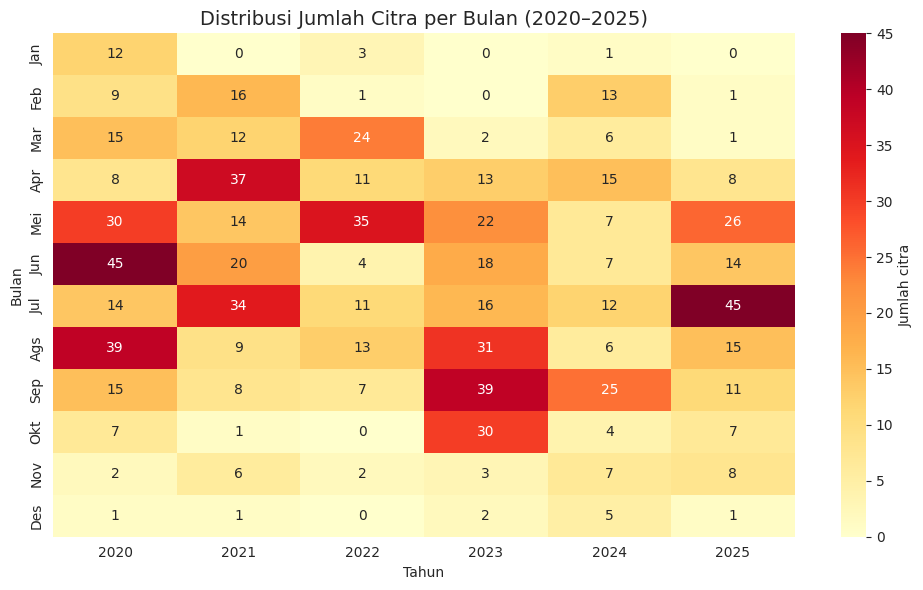

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Jumlah citra'})
plt.title('Distribusi Jumlah Citra per Bulan (2020–2025)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Bulan')
plt.tight_layout()
plt.show()

Di sini terlihat Citra 2025 menumpuk di Bulan Juli sedang 2024 sebaliknya.

**Perbandingan Citra di Musim Kemarau**

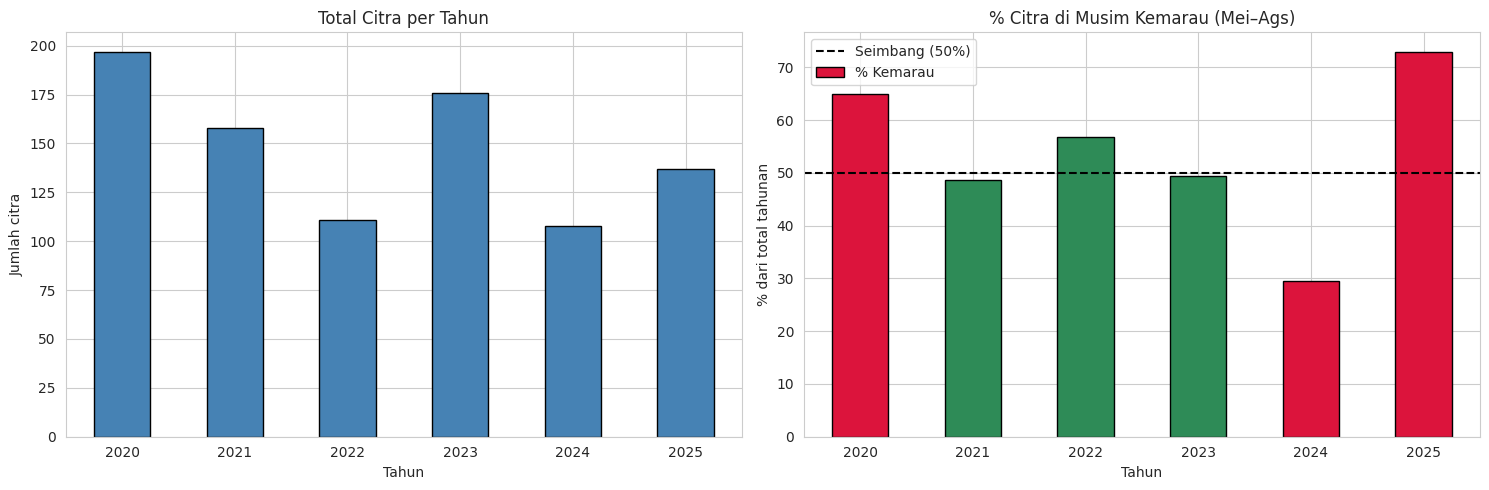

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel kiri: total citra
rekap['Total'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Citra per Tahun')
axes[0].set_ylabel('Jumlah citra')
axes[0].set_xlabel('Tahun')
axes[0].tick_params(axis='x', rotation=0)

# Panel kanan: % kemarau
colors = ['crimson' if v > 60 or v < 40 else 'seagreen'
          for v in rekap['% Kemarau']]
rekap['% Kemarau'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].axhline(50, color='black', linestyle='--', label='Seimbang (50%)')
axes[1].set_title('% Citra di Musim Kemarau (Mei–Ags)')
axes[1].set_ylabel('% dari total tahunan')
axes[1].set_xlabel('Tahun')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

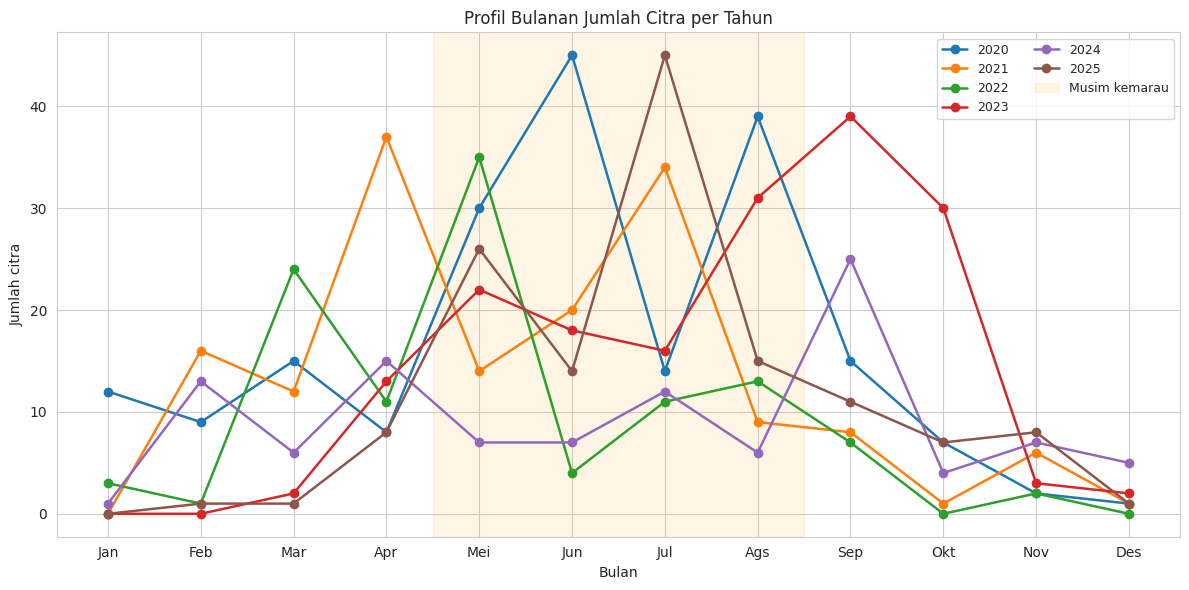

In [27]:
plt.figure(figsize=(12, 6))
for y in years:
    plt.plot(df.index, df[y], marker='o', label=str(y), linewidth=1.8)

plt.axvspan(3.5, 7.5, alpha=0.1, color='orange', label='Musim kemarau')
plt.title('Profil Bulanan Jumlah Citra per Tahun')
plt.xlabel('Bulan')
plt.ylabel('Jumlah citra')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

**Lihat Outliernya**

In [36]:
vals = np.array([65, 49, 57, 49, 30, 73])
mean, std = vals.mean(), vals.std(ddof=0)
z = (vals - mean) / std
print("Mean:", round(mean,1), "Std:", round(std,1))
print ("Z-Score:", z)

Mean: 53.8 Std: 13.6
Z-Score: [ 0.8184742  -0.35426495  0.23210462 -0.35426495 -1.74689269  1.40484377]


In [32]:
from scipy import stats

z = np.abs(stats.zscore(rekap['% Kemarau']))
rekap['Z-score'] = z.round(2)
rekap['Outlier'] = np.where(z > 1., 'KanYe', 'KanNo')

print(rekap[['Total','% Kemarau','Rasio K:H','Z-score','Outlier']])

      Total  % Kemarau  Rasio K:H  Z-score Outlier
2020    197       65.0       2.72     0.82   KanNo
2021    158       48.7       1.07     0.37   KanNo
2022    111       56.8       1.54     0.22   KanNo
2023    176       49.4       4.35     0.32   KanNo
2024    108       29.6       0.68     1.76   KanYe
2025    137       73.0       5.26     1.40   KanNo


Bisa dilihat bahwa 2024 adalah outlier di sini.
Sedang 2025, walau secara visualisasi ia merupakan outlier, ia lolos Z-score.

Hal ini disebabkan threshold tunggal rapuh di n kecil (6 tahun).

Tapi di luar itu, kita bisa flagging composite bias di Musim kemarau. Hal ini bisa didasari beberapa hal;
1. Faktor fisik   
Pada musim kemarau, tutupan awan lebih rendah, sehingga lebih banyak citra yang lolos filter kualitas, sedang  pada musim hujan, awan tebal, sehingga banyak yang terbuang

2. Faktor Kesediaan Akusisi  
Jumlah scene mentah perbulan relatif konstan (Sentinel-2 ~10/hari) namun dikarnakan data yang diambil adalah 2A, hasil citra ini adalah yang tersisa setelah cloud masking.



### NDVI dan Mask Cloud

In [39]:
def mask_clouds(image):
    scl = image.select('SCL')
    # SCL class 3 = cloud shadow, 8-10 = cloud (medium/high prob + cirrus), 11 = snow
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return image.updateMask(mask)

def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

In [42]:
collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2020-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_clouds)
    .map(add_ndvi))

In [41]:
composite_2020 = processed.filterDate('2020-01-01', '2020-12-31').median().clip(aoi)
ndvi_2020 = composite_2020.select('NDVI')

composite_2025 = processed.filterDate('2025-01-01', '2025-12-31').median().clip(aoi)
ndvi_2025 = composite_2025.select('NDVI')

## Deteksi Perubahan

In [43]:
def classify_ndvi(ndvi_image):
    """
    Klasifikasi kerapatan vegetasi (Al-Doski dkk., 2013):
      1 = Non-vegetasi     : -1  ≤ NDVI < 0.2
      2 = Vegetasi jarang  :  0.2 ≤ NDVI < 0.4
      3 = Vegetasi sedang  :  0.4 ≤ NDVI < 0.6
      4 = Vegetasi rapat   :  0.6 ≤ NDVI ≤ 1
    """
    return (ndvi_image
        .expression(
            "(b('NDVI') < 0.2) ? 1"
            ": (b('NDVI') < 0.4) ? 2"
            ": (b('NDVI') < 0.6) ? 3"
            ": 4"
        )
        .rename('NDVI_class')
        .byte())

### Meminimalisir Bias

Melihat pebandingan citra, untuk menghindari bias musim, kesemua data diambil di musim kemarau saja.

In [45]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
ndvi_yearly = {}
class_yearly = {}

for y in years:
    comp = (collection
            .filterDate(f'{y}-06-01', f'{y}-09-30')
            .median()
            .clip(aoi))
    ndvi_yearly[y]  = comp.select('NDVI')
    class_yearly[y] = classify_ndvi(comp.select('NDVI'))

### Visualisai Peta Kerapatan Vegetasi 2020-2025

In [48]:
maps = []
for y in years:
    m = geemap.Map(center=[-1.5, 113], zoom=7)
    m.addLayer(class_yearly[y], vis_class, f'Klasifikasi {y}')
    m.addLayer(aoi, {'color': 'black'}, 'Batas')
    m.add_legend(
        title=f'Kerapatan Vegetasi {y}',
        legend_dict={
            'Non-vegetasi'   : '#d7191c',
            'Vegetasi jarang': '#fdae61',
            'Vegetasi sedang': '#a6d96a',
            'Vegetasi rapat' : '#1a9850',
        })
    maps.append(m)

for m in maps:
    display(m)

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

### Analisis Luas per Kelas

In [56]:
def area_by_class(class_image, year=None):
    class_image = class_image.select('NDVI_class')

    # Band area dalam hektar
    area_ha = ee.Image.pixelArea().divide(1e4).rename('area')
    stack = area_ha.addBands(class_image.rename('class_id'))

    stats = stack.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,
            groupName='class'),
        geometry=aoi,
        scale=20,
        maxPixels=1e13,
        bestEffort=True
    ).getInfo()

    label = {1:'Non-vegetasi', 2:'Vegetasi jarang',
             3:'Vegetasi sedang', 4:'Vegetasi rapat'}

    rows = {g['class']: g['sum'] for g in stats.get('groups', [])}
    # Isi kelas yang kosong dengan 0
    result = {label[k]: round(rows.get(k, 0), 2) for k in [1,2,3,4]}
    return result

df_area = pd.DataFrame({y: area_by_class(class_yearly[y], y)
                        for y in years}).T
df_area.index.name = 'Tahun'
print(df_area)

       Non-vegetasi  Vegetasi jarang  Vegetasi sedang  Vegetasi rapat
Tahun                                                                
2020      222360.40        314940.95        879286.65     13951849.37
2021      129855.38        241665.37        627700.53     14369216.08
2022      123842.89         97058.86        305097.32     14842438.29
2023      215052.45        214491.71        580812.81     14358080.39
2024      188118.56        206091.36        533277.52     14440949.93
2025      205827.39        199808.62        542462.32     14420339.03


In [61]:
df_area.to_csv(f'{DATA_DIR}/tables/luas_kerapatan_ndvi_kalteng.csv')

### Rata-rata NDVI Spasial Per-Tahun

In [57]:
import datetime

years = list(range(2020, 2026))
ndvi_yearly_mean = []

for year in years:
    yearly_composite = (processed
        .filterDate(f'{year}-06-01', f'{year}-09-30')
        .median()
        .clip(aoi)
        .select('NDVI'))

    stats = yearly_composite.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=100,
        maxPixels=1e13
    )

    mean_val = stats.get('NDVI').getInfo()
    ndvi_yearly_mean.append(mean_val)
    print(f'{year}: {mean_val:.4f}')

2020: 0.7658
2021: 0.7558
2022: 0.7571
2023: 0.7525
2024: 0.7676
2025: 0.7766


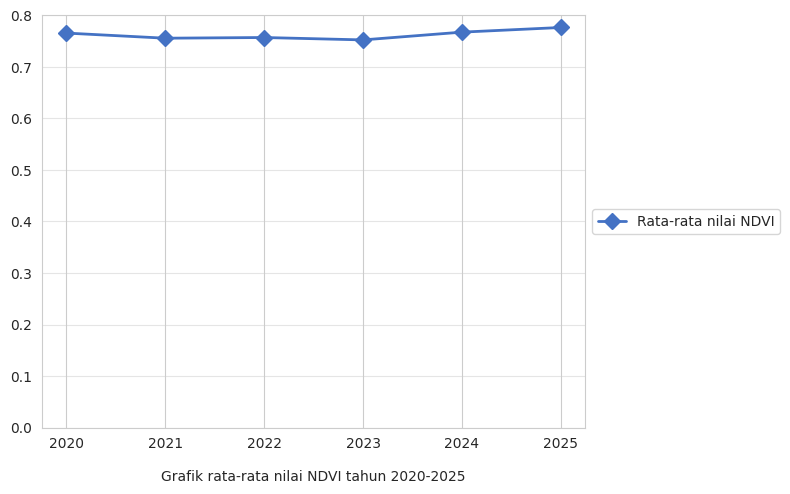

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(years, ndvi_yearly_mean, marker='D', color='#4472C4', linewidth=2, markersize=8, label='Rata-rata nilai NDVI')

plt.ylim(0, 0.8)
plt.yticks([i/10 for i in range(0, 9)])
plt.xticks(years)
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(f'Grafik rata-rata nilai NDVI tahun {years[0]}-{years[-1]}', y=-0.15, fontsize=10)

plt.tight_layout()
plt.savefig('ndvi_trend.png', dpi=300, bbox_inches='tight')
plt.show()

Angkanya masih tergolong sangat tinggi. Hal ini dikarnakan rata-rata ini dihitung untuk **seluruh provinsi Kalimantan Tengah (~15 juta hektar)**, yang mayoritas areanya adalah hutan primer/sekunder yang stabil dan tidak mengalami perubahan apa pun selama periode ini.

Walau kita dapat melihat perubahan vegetasi di peta, area yang benar-benar mengalami deforestasi (dari data Hansen, biasanya berupa titik/patch-patch kecil tersebar) itu secara proporsi luasnya sangat kecil dibanding total luas provinsi, jadi efeknya diluted dalam rata-rata keseluruhan. Perubahan lokal itu tidak akan terlihat di angka agregat sebesar itu.

### Dokumentasi Lanjutan

**GeoTiff**

In [69]:
EE_EXPORT_FOLDER = 'EE_Kalteng_NDVI'

tasks = []
for y in years:
    t = ee.batch.Export.image.toDrive(
        image=class_yearly[y].toByte(),
        description=f'class_kalteng_{y}',
        folder=EE_EXPORT_FOLDER,
        fileNamePrefix=f'class_kalteng_{y}',
        region=aoi, scale=20, maxPixels=1e13,
        crs='EPSG:4326', fileFormat='GeoTIFF'
    )
    t.start()
    tasks.append((y, t))
    print(f'Export {y} dimulai.')

# Ekspor peta perubahan
change_map = (ee.Image(0)
    .where(class_yearly[2020].eq(4).And(class_yearly[2025].eq(1)), 1)
    .where(class_yearly[2020].gte(3).And(class_yearly[2025].lte(2)), 2)
    .where(class_yearly[2020].lte(2).And(class_yearly[2025].gte(3)), 3)
    .selfMask().rename('change').byte())

ee.batch.Export.image.toDrive(
    image=change_map, description='perubahan_kalteng_2020_2025',
    folder=EE_EXPORT_FOLDER, fileNamePrefix='perubahan_kalteng_2020_2025',
    region=aoi, scale=20, maxPixels=1e13, crs='EPSG:4326'
).start()
print("Export peta perubahan dimulai.")

Export 2020 dimulai.
Export 2021 dimulai.
Export 2022 dimulai.
Export 2023 dimulai.
Export 2024 dimulai.
Export 2025 dimulai.
Export peta perubahan dimulai.


In [70]:
import time, shutil, glob

def wait_and_move(tasks, dest_dir, src_folder=EE_EXPORT_FOLDER,
                  timeout_min=60):
    src_path = f'/content/drive/MyDrive/{src_folder}'
    os.makedirs(dest_dir, exist_ok=True)
    t0 = time.time()
    pending = list(tasks)

    while pending and (time.time() - t0) < timeout_min*60:
        still = []
        for y, t in pending:
            state = t.status()['state']
            if state in ('COMPLETED','FAILED','CANCELLED'):
                print(f'  [{y}] {state}')
            else:
                still.append((y, t))
        pending = still
        if pending:
            time.sleep(20)

    moved = []
    for f in glob.glob(f'{src_path}/*.tif'):
        base = os.path.basename(f)
        target = os.path.join(dest_dir, base)
        if not os.path.exists(target):
            shutil.move(f, target)
            moved.append(base)
    print(f'Dipindahkan ke {dest_dir}:')
    for m in moved: print('  -', m)
    return moved

wait_and_move(tasks, dest_dir=f'{DATA_DIR}/rasters')

  [2020] COMPLETED
  [2021] COMPLETED
  [2022] COMPLETED
  [2023] COMPLETED


  [2024] COMPLETED
Dipindahkan ke /content/drive/MyDrive/skripsi_data/rasters:
  - class_kalteng_2020.tif
  - class_kalteng_2021.tif
  - class_kalteng_2022.tif
  - class_kalteng_2023.tif
  - class_kalteng_2024.tif


['class_kalteng_2020.tif',
 'class_kalteng_2021.tif',
 'class_kalteng_2022.tif',
 'class_kalteng_2023.tif',
 'class_kalteng_2024.tif']

**Peta PNG**

In [72]:
import os
import geemap
from IPython.display import display

output_dir = f'{DATA_DIR}/maps'
os.makedirs(output_dir, exist_ok=True)

maps = []

for y in years:

    m = geemap.Map(
        center=[-1.5, 113],
        zoom=7
    )

    m.addLayer(
        class_yearly[y],
        vis_class,
        f'Klasifikasi {y}'
    )

    m.addLayer(
        aoi,
        {'color': 'black'},
        'Batas'
    )

    m.add_legend(
        title=f'Kerapatan Vegetasi {y}',
        legend_dict={
            'Non-vegetasi': '#d7191c',
            'Vegetasi jarang': '#fdae61',
            'Vegetasi sedang': '#a6d96a',
            'Vegetasi rapat': '#1a9850',
        }
    )

    maps.append(m)

    display(m)

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [76]:
!pip install mss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.9 MB/s eta 0:00:00


In [79]:
for y, m in zip(years, maps):

    output_file = f'{output_dir}/kerapatan_vegetasi_{y}.png'

    m.to_image(
        filename=output_file,
        monitor=1
    )

    print(f'Tersimpan: {output_file}')

Cannot connect to display: display is unset or invalid (check $DISPLAY)
Tersimpan: /content/drive/MyDrive/skripsi_data/maps/kerapatan_vegetasi_2020.png
Cannot connect to display: display is unset or invalid (check $DISPLAY)
Tersimpan: /content/drive/MyDrive/skripsi_data/maps/kerapatan_vegetasi_2021.png
Cannot connect to display: display is unset or invalid (check $DISPLAY)
Tersimpan: /content/drive/MyDrive/skripsi_data/maps/kerapatan_vegetasi_2022.png
Cannot connect to display: display is unset or invalid (check $DISPLAY)
Tersimpan: /content/drive/MyDrive/skripsi_data/maps/kerapatan_vegetasi_2023.png
Cannot connect to display: display is unset or invalid (check $DISPLAY)
Tersimpan: /content/drive/MyDrive/skripsi_data/maps/kerapatan_vegetasi_2024.png
Cannot connect to display: display is unset or invalid (check $DISPLAY)
Tersimpan: /content/drive/MyDrive/skripsi_data/maps/kerapatan_vegetasi_2025.png


**Gif**

In [64]:
frames = []
for y in years:
    img = fetch_tile(get_tile_url(class_yearly[y], vis_class), bbox_kalteng)
    frames.append(np.array(img.convert('RGB')))

gif_path = f'{DATA_DIR}/anim/kerapatan_kalteng_2020_2025.gif'
imageio.mimsave(gif_path, frames, duration=1.2, loop=0)
print(f"Tersimpan: {gif_path}")

NameError: name 'fetch_tile' is not defined